In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import warnings

# Package Imports
import torch
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt

import torch.nn as nn
from torch.optim.optimizer import Optimizer
from torch.optim.lr_scheduler import _LRScheduler
from typing import Tuple

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils as utils
from typing import Tuple
from torch.optim.optimizer import Optimizer
from torch.optim.lr_scheduler import _LRScheduler
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import ipywidgets as widgets
from IPython.display import display, clear_output


In [2]:
features_path = "data/friction_data/features_AgingLaw_v2.csv"
targets_path = "data/friction_data/targets_AgingLaw_v2.csv"
train_samples = 700

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def x_log_transform(x: np.array) -> torch.Tensor:
    return torch.Tensor(np.log(np.log(1/x)))

def x_state_transform(x: np.array) -> torch.Tensor:
    return torch.Tensor(np.sqrt(np.log(1e8*x)))

def x_heal_transform(x: np.array) -> torch.Tensor:
    return (torch.abs(torch.Tensor(x) - 1e-8) < 1e-12).float()

In [4]:
feature = np.genfromtxt(features_path, delimiter=',')[:, np.newaxis, :]
target = np.genfromtxt(targets_path, delimiter=',')[:, np.newaxis, :]

train_x = feature[:train_samples, :, :]
train_y = target[:train_samples, :, :]
test_x = feature[train_samples:, :, :]
test_y = target[train_samples:, :, :]

data = {"train_x": train_x,
        "train_y": train_y,
        "test_x": test_x,
        "test_y": test_y}

train_norm_components = []
test_norm_components = []

train_x_norm_log = x_log_transform(train_x)
x_max = train_x_norm_log.max()
train_x_norm_log /= x_max
test_x_norm_log = x_log_transform(test_x) / x_max

train_norm_components.append(train_x_norm_log)
test_norm_components.append(test_x_norm_log)
data['train_x_norm_log'] = train_x_norm_log
data['test_x_norm_log'] = test_x_norm_log

train_x_norm = torch.cat(train_norm_components, dim=1)
test_x_norm = torch.cat(test_norm_components, dim=1)
    
train_y_norm = torch.Tensor(train_y / train_y.max())
test_y_norm = torch.Tensor(test_y / train_y.max())

train_dataset = TensorDataset(train_x_norm.to(device), train_y_norm.to(device))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

data["train_x_norm"] = train_x_norm.to(device)
data['test_x_norm'] = test_x_norm.to(device)
data['train_y_norm'] = train_y_norm.to(device)
data['test_y_norm'] = test_y_norm.to(device)
data['train_dataset'] = train_dataset
data['train_loader'] = train_loader

In [5]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

class SpectralConv1d(nn.Module):
    def __init__(self, 
                 in_channels : int, 
                 out_channels: int, 
                 modes: int):

        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        scale = 1.0 / (in_channels * out_channels)
        self.real_weights = nn.Parameter(
            torch.rand(in_channels, out_channels, modes) * 2 * scale - scale
        )
        self.imag_weights = nn.Parameter(
            torch.rand(in_channels, out_channels, modes) * 2 * scale - scale
        )

    def forward(self, x):
        # x: (batch, channels, spatial_points)
        batchsize, channels, spatial_points = x.shape

        x_hat = torch.fft.rfft(x, dim=-1)  # (B, C, F)
        x_hat_under_modes = x_hat[:, :, :self.modes]

        weights = torch.complex(self.real_weights, self.imag_weights)
        out_hat_under_modes = torch.einsum("bim, iom -> bom", x_hat_under_modes, weights)

        out_hat = torch.zeros(
            batchsize, self.out_channels, x_hat.shape[-1],
            dtype=torch.cfloat, device=x.device
        )
        out_hat[:, :, :self.modes] = out_hat_under_modes

        out = torch.fft.irfft(out_hat, n=spatial_points, dim=-1)
        return out


class FNOBlock1d(nn.Module):
    def __init__(self, 
                 in_channels : int, 
                 out_channels : int, 
                 modes : int, 
                 activation : nn.Module = nn.Identity()):
        
        super().__init__()

        self.activation = activation

        self.spectral_conv = SpectralConv1d(in_channels, out_channels, modes)
        self.bypass_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        sc = self.spectral_conv(x)
        bc = self.bypass_conv(x)
        out = sc + bc
        return self.activation(out)

class ConvNet1d(nn.Module):
  
    def __init__(self, 
                 in_channels: int, 
                 out_channels: int, 
                 activation: nn.Module = nn.Identity()):
        super().__init__()


        self.net = nn.Sequential(nn.Conv1d(in_channels, out_channels, kernel_size = 1, bias = False),
                                     activation)

    def forward(self, x):
        return self.net(x)

class FNO1d(nn.Module):
    def __init__(
        self,
        in_channels : int,
        out_channels : int,
        modes : int,
        width : int,
        n_blocks : int = 4,
        block_activation : nn.Module = nn.Identity(),
        lift_activation : nn.Module = nn.Identity(),
        decode_activation : nn.Module = nn.Identity(),
    ):

        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.width = width
        self.block_activation = block_activation
        self.n_blocks = n_blocks
        self.lift_activation = lift_activation
        self.decode_activation = decode_activation


        self.lift_network = ConvNet1d(in_channels = self.in_channels, 
                                        out_channels = self.width, 
                                        activation = self.lift_activation)
                    
        self.decode_network = ConvNet1d(self.width,
                                        self.out_channels,
                                        self.decode_activation)

        self.fno_blocks = nn.ModuleList([
            FNOBlock1d(width, width, modes, block_activation)
            for _ in range(n_blocks)
        ])

        self.apply(init_weights)

    # x: (B, C, N)
    def forward(self, x):

        x = self.lift_network(x)

        for block in self.fno_blocks:
            x = block(x)

        x = self.decode_network(x)

        return x

In [9]:
in_channels = data['train_x_norm'].shape[1]
out_channels = data['train_y_norm'].shape[1]

model = FNO1d(
        in_channels       = in_channels,
        out_channels      = out_channels,
        modes             = 12,
        width             = 32,
        block_activation  = torch.nn.GELU(),
        n_blocks          = 4,
        lift_activation   = torch.nn.GELU(),
        decode_activation = torch.nn.SiLU()).to(device)

In [10]:
def train_loop(model: nn.Module,
               train_loader: DataLoader,
               val_x: torch.Tensor,
               val_y: torch.Tensor,
               epochs: int,
               optimizer: Optimizer,
               scheduler: _LRScheduler,
               criterion: nn.modules.loss._Loss = nn.MSELoss(),
               save_results: bool = True,
               clip_grad: bool = False,
               verbose: bool = False,
               sample_freq: int = 1) -> Tuple[list, list]:
    
    loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            
            
            output = model(batch_x[:,:,::sample_freq])
            loss = criterion(output, batch_y[:,:,::sample_freq])

            loss.backward()

            if clip_grad:
                utils.clip_grad_norm_(model.parameters(), 0.5)

            optimizer.step()
            epoch_loss += loss.item()
            scheduler.step()

        if save_results or epoch == epochs -1:
            loss_history.append(epoch_loss / len(train_loader))
            
            model.eval()
            with torch.no_grad():
                val_output = model(val_x)
                val_loss = criterion(val_output, val_y).item()
                val_loss_history.append(val_loss)

            if verbose:
                print(f"EPOCH {epoch}: train_loss: {loss.item():.3e} \t test_loss: {val_loss:.3e}")

    return loss_history, val_loss_history

In [11]:
def make_decay_fn(factor: float, 
                  interval: int):
    return lambda step: factor ** (step // interval)

In [14]:
criterion = nn.MSELoss()
lr = 1e-3

optimizer = optim.Adam(model.parameters(), lr=lr)
    
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda= make_decay_fn(0.9, 1000))

loss_history, val_loss_history = [], []
train_loader, test_x, test_y = data['train_loader'], data['test_x_norm'], data['test_y_norm']

loss_history, val_loss_history = train_loop(model, train_loader, test_x, test_y,
                                            25, optimizer, scheduler, 
                                            criterion, True, False, True, 1)

data['loss_history'] = loss_history
data['val_loss_history'] = val_loss_history

EPOCH 0: train_loss: 1.809e-02 	 test_loss: 1.136e-02
EPOCH 1: train_loss: 9.675e-03 	 test_loss: 1.146e-02
EPOCH 2: train_loss: 1.044e-02 	 test_loss: 1.148e-02
EPOCH 3: train_loss: 1.184e-02 	 test_loss: 1.126e-02
EPOCH 4: train_loss: 1.108e-02 	 test_loss: 1.125e-02
EPOCH 5: train_loss: 2.478e-02 	 test_loss: 1.133e-02
EPOCH 6: train_loss: 1.332e-02 	 test_loss: 1.124e-02
EPOCH 7: train_loss: 1.141e-02 	 test_loss: 1.141e-02
EPOCH 8: train_loss: 1.222e-02 	 test_loss: 1.122e-02
EPOCH 9: train_loss: 1.377e-02 	 test_loss: 1.131e-02
EPOCH 10: train_loss: 1.080e-02 	 test_loss: 1.118e-02
EPOCH 11: train_loss: 7.697e-03 	 test_loss: 1.118e-02
EPOCH 12: train_loss: 7.183e-03 	 test_loss: 1.108e-02
EPOCH 13: train_loss: 1.102e-02 	 test_loss: 1.105e-02
EPOCH 14: train_loss: 1.028e-02 	 test_loss: 1.109e-02
EPOCH 15: train_loss: 1.552e-02 	 test_loss: 1.110e-02
EPOCH 16: train_loss: 8.178e-03 	 test_loss: 1.148e-02
EPOCH 17: train_loss: 1.297e-02 	 test_loss: 1.119e-02
EPOCH 18: train_loss

In [15]:
def plot_data(x, y, name):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    axes = axes.flatten()
    
    for i in range(16):
        ax1 = axes[i]
        ax1.plot(x[i], label='Input' if i == 0 else "")
        ax1.plot(y[i], label='Output' if i == 0 else "")
        ax1.set_xticks([])
        ax1.tick_params(axis='y', labelsize=14)  # Bigger y-ticks

    fig.suptitle(name, fontsize=22, y=0.98)  # Title closer to top

    # Legend below the title, slightly lower than before
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.93])  # Leave space for title+legend
    plt.show()


def plot_results(model: torch.nn.Module, 
                 x: torch.Tensor, 
                 y: torch.Tensor, 
                 name: str,
                 save: bool = False) -> None:

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    axes = axes.flatten()
    for i in range(16):
        pred = model(x[i:i+1])[0].cpu().detach().numpy()
        ax1 = axes[i]

        ax1.plot(y[i, 0, :].cpu().detach().numpy(), color='tab:orange', label='Ground Truth' if i == 0 else "")
        ax1.plot(pred[0], color='tab:green', label='Prediction' if i == 0 else "")
        ax1.set_xticks([])
        ax1.set_yticks([])

    fig.suptitle(name, fontsize=22, y=0.98)  # Title closer to top

    # Legend below the title, slightly lower than before
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for legend on top
    if save:
        fig.savefig(name, dpi=300, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_loss(loss: list, val: list, name: str, save:bool = False) -> None:

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(loss, label="train loss")
    ax.plot(val, label="val loss")
    ax.legend(fontsize=14)
    ax.set_yscale("log")
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=14)
    fig.suptitle(name, fontsize=18)
    plt.tight_layout()
    return fig

def plots(model: torch.nn.Module, data: dict, device: torch.device) -> None:

    train_x_norm = data['train_x_norm']
    train_y_norm = data['train_y_norm']
    test_x_norm = data['test_x_norm']
    test_y_norm = data['test_y_norm']

    # PLOT 1 - Loss plot
    if 'loss_history' in data:
        loss_history = data['loss_history']
        val_loss_history = data['val_loss_history']
        plot_loss(loss_history, val_loss_history, "loss_plot.png")
    
    # Plot 2 - Inference on Training Set
    plot_results(model, train_x_norm, train_y_norm, "train_inference.png")
    
    # Plot 3 - Inference on Testing Set
    plot_results(model, test_x_norm, test_y_norm, "test_inference.png")

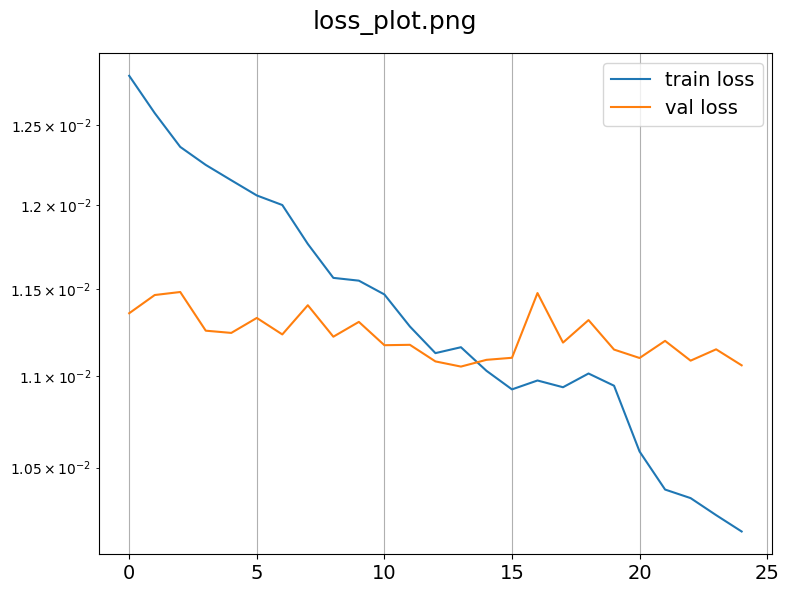

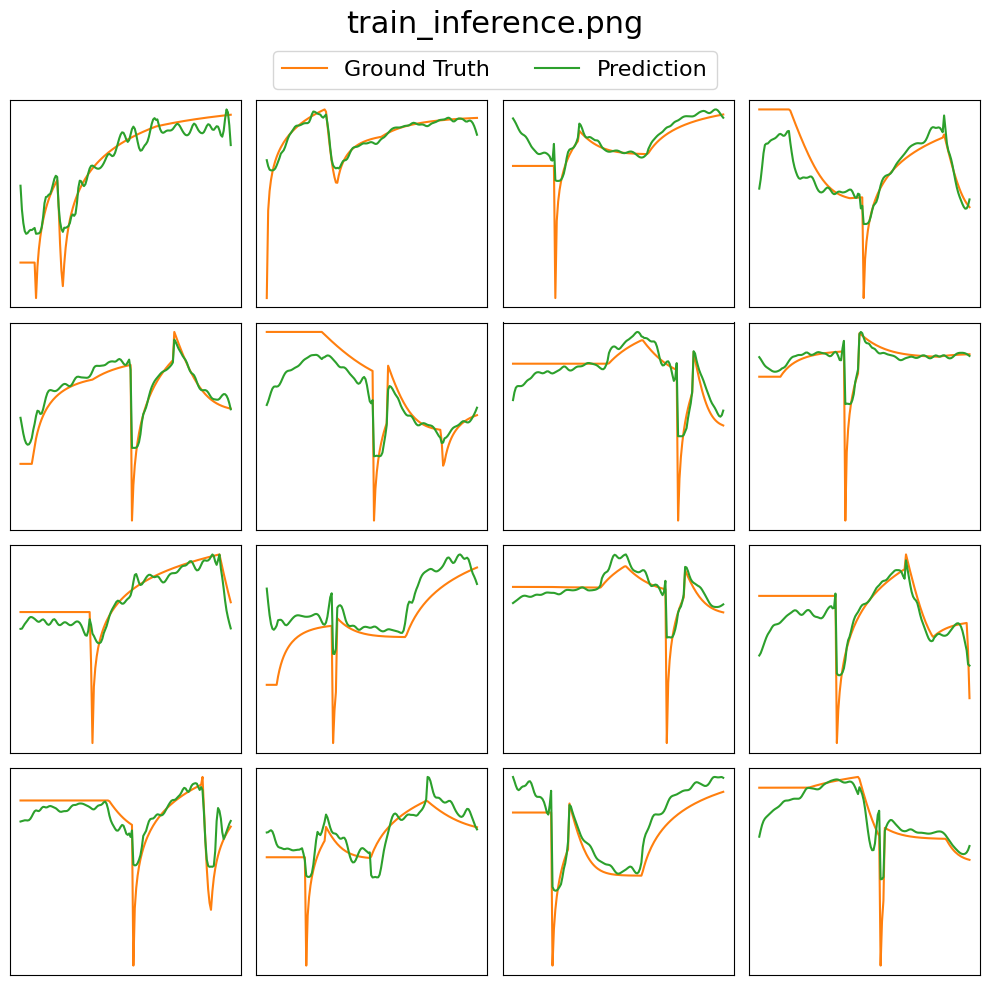

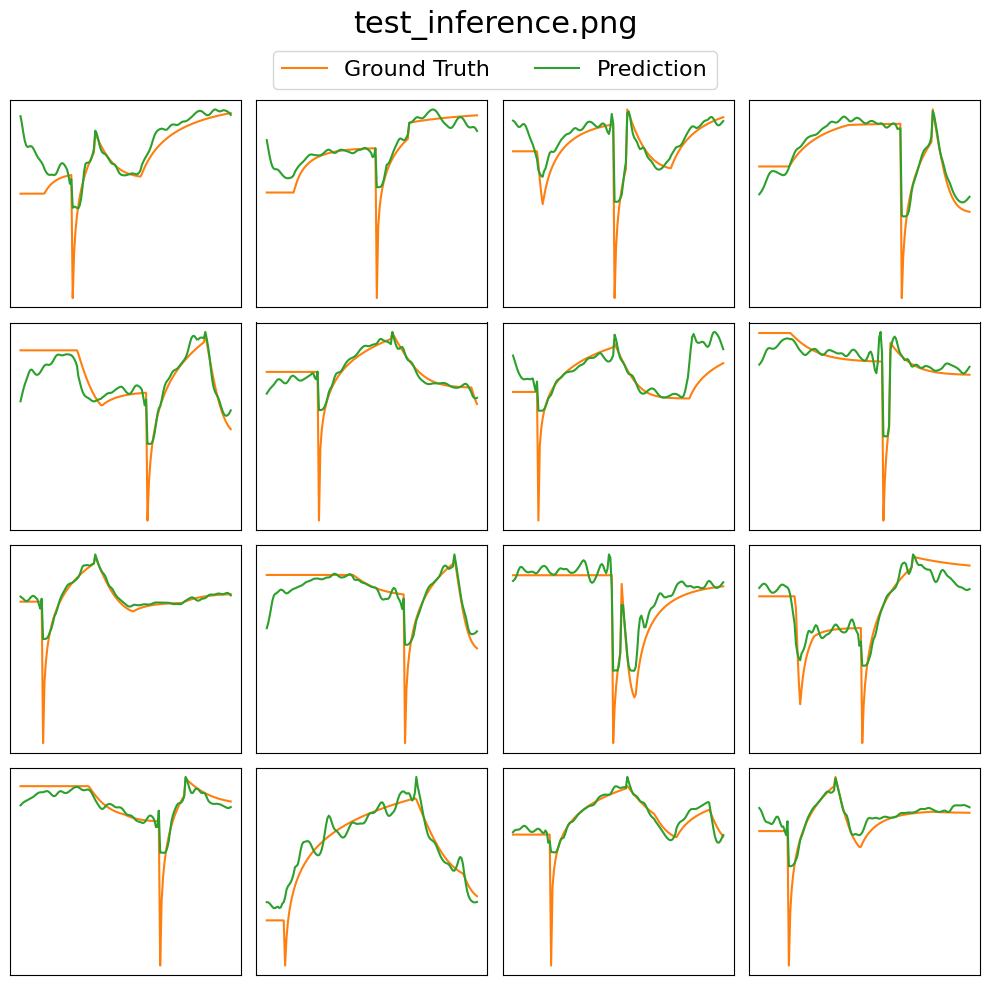

In [16]:
plots(model, data, device)